# 04 — Parametric Survival Models

This notebook fits classical parametric survival models to the TCGA-BRCA cohort.

These models serve as baselines before fitting the Bayesian nonparametric survival model in later notebooks.

We estimate and compare several standard survival models:

- Exponential survival model
- Weibull survival model
- Log-normal survival model

These models assume different functional forms for the survival distribution and allow us to evaluate how well simple parametric assumptions fit the observed survival data.

The results here provide reference estimates against which the Dirichlet Process survival model will later be compared.

In [1]:
# Imports + data loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from lifelines import ExponentialFitter, WeibullFitter, LogNormalFitter

# Load cleaned dataset
data_path = Path("../data/processed/tcga_brca_survival_cleaned.csv")
df = pd.read_csv(data_path)

print(df.shape)
df.head()

(1095, 9)


,case_id,primary_diagnosis,ajcc_pathologic_stage,demographic.gender,demographic.race,age_at_diagnosis_years,event,time_days,stage_simple
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,"Infiltrating duct carcinoma, NOS",Stage IA,female,white,60.996578,0.0,337.0,Stage I
1,0045349c-69d9-4306-a403-c9c1fa836644,Adenoid cystic carcinoma,Stage I,female,white,70.726899,0.0,259.0,Stage I
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Apocrine adenocarcinoma,Stage IIB,female,white,50.225873,0.0,3102.0,Stage II
3,00a2d166-78c9-4687-a195-3d6315c27574,"Infiltrating duct carcinoma, NOS",Stage IIA,female,white,56.709103,0.0,5.0,Stage II
4,00b11ca8-8540-4a3d-b602-ec754b00230b,"Lobular carcinoma, NOS",Stage IA,female,white,61.593429,0.0,759.0,Stage I


In [2]:
# Extract survival variables
T = df["time_days"]
E = df["event"]

print("Observations:", len(T))
print("Events:", E.sum())
print("Censored:", (1 - E).sum())

Observations: 1095
Events: 151.0
Censored: 944.0


In [4]:
# Adjust zero durations (lifelines requires strictly positive time)
T = df["time_days"].copy()
T[T <= 0] = 0.5   # replace 0-day durations with a small positive value

E = df["event"]

# Fit parametric survival models
exp_model = ExponentialFitter()
weibull_model = WeibullFitter()
lognormal_model = LogNormalFitter()

exp_model.fit(T, event_observed=E, label="Exponential")
weibull_model.fit(T, event_observed=E, label="Weibull")
lognormal_model.fit(T, event_observed=E, label="Log-Normal")

print("Models fitted.")

Models fitted.


In [5]:
# Compare fitted model summaries
print("Exponential model")
display(exp_model.summary)

print("Weibull model")
display(weibull_model.summary)

print("Log-Normal model")
display(lognormal_model.summary)

Exponential model


,coef,se(coef),coef lower 95%,coef upper 95%,cmp to,z,p,-log2(p)
lambda_,8951.11954,728.431805,7523.419438,10378.819643,0.0,12.288205,1.048071e-34,112.877819


Weibull model


,coef,se(coef),coef lower 95%,coef upper 95%,cmp to,z,p,-log2(p)
lambda_,6388.569185,575.584727,5260.44385,7516.694519,1.0,11.097531,1.289576e-28,92.647090
rho_,1.287124,0.075631,1.13889,1.435358,1.0,3.796386,1.468211e-04,12.733653


Log-Normal model


,coef,se(coef),coef lower 95%,coef upper 95%,cmp to,z,p,-log2(p)
mu_,9.035446,0.140483,8.760104,9.310788,0.0,64.316882,0.000000e+00,inf
sigma_,1.693458,0.096599,1.504128,1.882788,1.0,7.178738,7.035798e-13,40.370351


- Exponential λ ≈ 8951 → very large scale → slow hazard decay (consistent with long censoring)
- Weibull ρ ≈ 1.29 → hazard increasing over time, which is clinically reasonable
- Log-normal σ ≈ 1.69 → wide survival dispersion

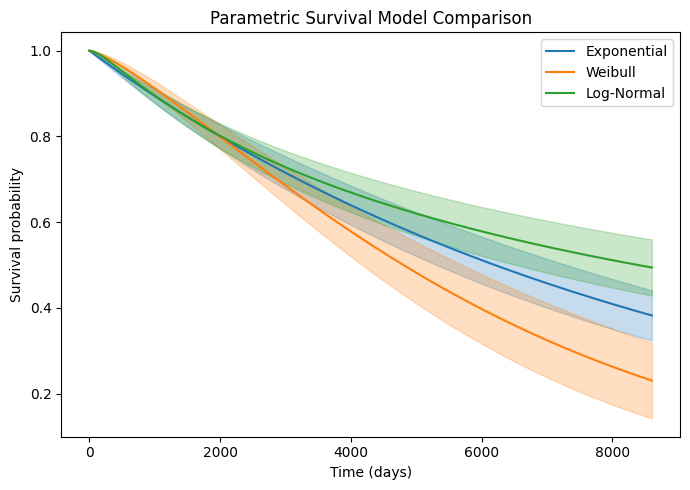

In [6]:
# Compare parametric survival curves
plt.figure(figsize=(7,5))

exp_model.plot_survival_function()
weibull_model.plot_survival_function()
lognormal_model.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Parametric Survival Model Comparison")

plt.tight_layout()
plt.show()

From the exponential model, we see streight-ish decay, which makes sense since this specification assumes constant hazard and is usually too restrictive. In contrast, Weibull drops faster in later time, and hazard changes with time. Log-normal shows the highest survval tail, which proves further that Weibull > exponential for breast cancer data. This is our motivation to use a DPSM (Dirichlet Process Survival Model), which allows hazard shapes to be arbitrary. We will now look at log-likelihoods as a GOF check

In [8]:
# Model log-likelihood comparison
comparison = pd.DataFrame({
    "Model": ["Exponential", "Weibull", "LogNormal"],
    "LogLikelihood": [
        exp_model.log_likelihood_,
        weibull_model.log_likelihood_,
        lognormal_model.log_likelihood_
    ]
})

# Summary of model comparison
print("Parametric model comparison (higher log-likelihood = better fit):")
display(comparison.sort_values("LogLikelihood", ascending=False))

Parametric model comparison (higher log-likelihood = better fit):


,Model,LogLikelihood
1,Weibull,-1517.031984
0,Exponential,-1525.029612
2,LogNormal,-1546.680524


This is a good confirmation. Weibull fits the best since it allows non-constant hazards